# ExplainPhish: Word Phishing Detection Tutorial
This NOTEBOOK provides a comprehensive end-to-end workflow for detecting malicious and phishing Word documents using machine learning and explainable AI.

**Objective**: To predict whether a Word document (`.docx`, `.docm`, `.doc`) is Phishing (`1`) or Benign (`0`) based on static macro, OLE, and OpenXML structural features extracted from the **CIC-Trap4Phish2025** benchmark.

**Evaluation metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) and Accuracy.

**Data Hygiene & Robustness**:
- **Missing Data Handling**: Deep analysis of structural missingness (30 OpenXML columns have 10,000 NaNs corresponding to legacy `.doc` files lacking OOXML packaging). Handled via domain-accurate zero imputation (`df.fillna(0)`).
- **Class Balance**: 10,000 Benign vs. 10,000 Phishing samples (50.0% / 50.0% balanced dataset).
- **Stratified Validation**: Stratified sampling across all partitions with cost-sensitive weighting (`class_weight='balanced'`).

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning, Identifier Creation & Stratified Splitting](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Missing Value Analysis & OOXML Missingness Handling](#scrollTo=missing_analysis)
  - [2.5 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.6 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.7 Word Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
- [3. Visualizing and Understanding the Data](#scrollTo=sec3)
  - [3.1 Checking Missing Values](#scrollTo=sec3_1)
  - [3.2 Visualization and Analysis of Each Feature](#scrollTo=sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#scrollTo=sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#scrollTo=sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness)](#scrollTo=sec3_2_3)
    - [3.2.4 OpenXML Structural Tags & Typography Attributes](#scrollTo=sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#scrollTo=sec3_2_5)
    - [3.2.6 Path Attributes & Hyperlink Density](#scrollTo=sec3_2_6)
    - [3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap](#scrollTo=sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#scrollTo=sec3_3)
- [4. Preprocessing and Feature Creation](#scrollTo=sec4)
- [5. Building the Machine Learning Model](#scrollTo=sec5)
  - [5.1 Import Additional Libraries](#scrollTo=sec5_1)
  - [5.2 Preparing the Data & Standardization](#scrollTo=sec5_2)
  - [5.3 Training the Model (Holdout 70/30 Stratified Validation)](#scrollTo=sec5_3)
  - [5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression](#scrollTo=sec5_4)
    - [5.4.1 Logistic Regression Visualizations (Coefficients & Calibration)](#scrollTo=sec5_4_1)
    - [5.4.2 Decision Tree Visualizations (Tree Graph & Feature Importance)](#scrollTo=sec5_4_2)
    - [5.4.3 Random Forest Visualizations (MDI Importance with Error Bars)](#scrollTo=sec5_4_3)
    - [5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, Metrics)](#scrollTo=sec5_4_4)
  - [5.5 (Optional) Use Voting Learning of 3 Different Models](#scrollTo=sec5_5)
  - [5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)](#scrollTo=sec5_6)
- [6. Creating Prediction Results](#scrollTo=sec6)
  - [6.1 Predicting on the Test Data](#scrollTo=sec6_1)
  - [6.2 Saving the Prediction as CSV File in 'word output' Folder](#scrollTo=sec6_2)


<a name="setup"></a>
## 1. Setup & Environment
Configure runtime, plotting styles, and path resolution for Word phishing detection.


<a name="import_libraries"></a>
### 1.1 Import Libraries
Import analytical and visualization libraries.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")


Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
Dynamically search candidate locations for `Word_All_features.csv`.


In [2]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "word" / "Word_All_features.csv",
    current_dir / "googleCollab" / "data" / "word" / "Word_All_features.csv",
    Path("data/word/Word_All_features.csv"),
    Path("googleCollab/data/word/Word_All_features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/word/Word_All_features.csv"),
    Path("/content/Word_All_features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find Word_All_features.csv. Please check the data directory.")

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\word\Word_All_features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview
Load the Word dataset, analyze structural missingness, impute missing XML tag existence counts, and create stratified splits.


<a name="raw_loading"></a>
### 2.1 Raw Loading
Load raw dataset.


In [3]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 20,000 rows x 44 columns


,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,struct_val,struct_typeface,struct_script,path_/w-p,path_w-r,path_/w-r,path_a-hlink,path_w-p,path_a-accent3,struct_ang,path_/a-effectLst,path_a-themeElements,struct_dist,path_a-alpha,struct_Extension,path_a-dk1,path_a-ln,path_/a-accent6,struct_w,struct_name,path_a-lt2,path_/a-outerShdw,path_a-accent4,path_/a-dk1,path_a-accent1,path_a-sysClr,path_a-lt1,path_/a-accent4,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz,path_a-solidFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId,label
0,21,3,1,0,2,5.2969,0,0,223813,0,0,0,0,NaN,NaN,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,1
1,0,0,0,1,0,7.4154,14,11,40156,10,69,66,60,31.0000,31.0000,31.0000,NaN,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2200.0000,NaN,938.0000,8.0000,324.0000,0
2,0,0,0,1,0,7.5955,15,11,258403,0,69,66,60,85.0000,195.0000,195.0000,NaN,95.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2283.0000,NaN,938.0000,0.0000,324.0000,0
3,0,0,0,1,0,7.4024,14,11,39924,10,69,66,60,31.0000,31.0000,31.0000,NaN,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2200.0000,NaN,938.0000,8.0000,324.0000,0
4,20,3,1,0,2,4.5188,0,0,199559,0,0,0,0,NaN,NaN,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,1


<a name="data_cleaning"></a>
### 2.2 Data Cleaning, Identifier Creation & Stratified Splitting
We generate synthetic sample identifiers (`sample_00001.docx` to `sample_20000.docx`), handle missing values by filling `0` (matching extractor behavior where absent XML tags have count 0), and perform a stratified 60/40 train/test split.


In [4]:
from sklearn.model_selection import train_test_split

df = raw_df.copy()
df["file_name"] = [f"sample_{i+1:05d}.docx" for i in range(len(df))]
df["TARGET"] = df["label"]

# Impute missing values: in Word document static extraction, missing OpenXML tags default to 0
df = df.fillna(0)

# Top 10 discriminative Word features matching ExplainPhishModel schema
core_features = [
    "struct_pos",
    "struct_typeface",
    "path_a-hlink",
    "path_a-accent3",
    "struct_script",
    "struct_ang",
    "path_/a-effectLst",
    "path_a-alpha",
    "path_/a-accent6",
    "struct_name"
]

# Reorder columns
df = df[["file_name"] + core_features + ["TARGET"]]

# Stratified 60% Train / 40% Test Split
train, test = train_test_split(
    df, test_size=0.40, stratify=df["TARGET"], random_state=42
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Train split: {train.shape[0]:,} rows | Test split: {test.shape[0]:,} rows")
df.head(5)


Cleaned Dataset Dimensions: 20,000 rows x 12 columns
Train split: 12,000 rows | Test split: 8,000 rows


,file_name,struct_pos,struct_typeface,path_a-hlink,path_a-accent3,struct_script,struct_ang,path_/a-effectLst,path_a-alpha,path_/a-accent6,struct_name,TARGET
0,sample_00001.docx,0,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,1
1,sample_00002.docx,10,66,0.0000,0.0000,60,0.0000,0.0000,0.0000,0.0000,0.0000,0
2,sample_00003.docx,0,66,0.0000,0.0000,60,0.0000,0.0000,0.0000,0.0000,0.0000,0
3,sample_00004.docx,10,66,0.0000,0.0000,60,0.0000,0.0000,0.0000,0.0000,0.0000,0
4,sample_00005.docx,0,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,1


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the feature types and non-null counts.


In [5]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   file_name          12000 non-null  str    
 1   struct_pos         12000 non-null  int64  
 2   struct_typeface    12000 non-null  int64  
 3   path_a-hlink       12000 non-null  float64
 4   path_a-accent3     12000 non-null  float64
 5   struct_script      12000 non-null  int64  
 6   struct_ang         12000 non-null  float64
 7   path_/a-effectLst  12000 non-null  float64
 8   path_a-alpha       12000 non-null  float64
 9   path_/a-accent6    12000 non-null  float64
 10  struct_name        12000 non-null  float64
 11  TARGET             12000 non-null  int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 1.1 MB


<a name="missing_analysis"></a>
### 2.4 Missing Value Analysis & OOXML Missingness Handling
In Word phishing analysis:
- Modern `.docx` files contain zipped XML packages (`word/document.xml`, `theme/theme1.xml`, etc.).
- Legacy `.doc` binary OLE files completely lack these XML streams.
- Thus, raw features extracted from legacy files produce `NaN` for OpenXML tag counts.
- Imputing with `0` reflects the true physical count of those tags in the document.


In [6]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column after domain imputation:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: All features are completely imputed and ready for modeling.")


Missing values per column after domain imputation:
file_name            0
struct_pos           0
struct_typeface      0
path_a-hlink         0
path_a-accent3       0
struct_script        0
struct_ang           0
path_/a-effectLst    0
path_a-alpha         0
path_/a-accent6      0
struct_name          0
TARGET               0
dtype: int64

Overall missing values: 0 / 144000 (0.00%)
Confirmation: All features are completely imputed and ready for modeling.


<a name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute summary statistics for the 10 core Word features.


In [7]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
struct_pos,6.5544,4.5827,0.0000,0.0000,9.0000,10.0000,11.0000,10.0000
struct_typeface,49.1768,35.7028,0.0000,0.0000,66.0000,66.0000,100.0000,66.0000
path_a-hlink,0.1777,0.3823,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
path_a-accent3,0.1777,0.3823,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
struct_script,45.1123,33.0481,0.0000,0.0000,60.0000,60.0000,94.0000,60.0000
struct_ang,0.5332,1.1468,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_/a-effectLst,0.1779,0.3831,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_a-alpha,0.1779,0.3831,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_/a-accent6,0.1777,0.3823,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
struct_name,0.8878,1.9099,0.0000,0.0000,0.0000,0.0000,5.0000,0.0000


<a name="class_balance"></a>
### 2.6 Target Class Balance Analysis
Verify the balance of `TARGET`.


In [8]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).")


,Sample Count,Percentage (%)
TARGET,,
Benign (0),6000,50.0000
Phishing (1),6000,50.0000


Imbalance Ratio (Phishing : Benign) = 1.000 : 1.000
Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).


<a name="feature_definitions"></a>
### 2.7 Word Feature Definitions & Threat Relevance
Understanding how each feature reflects Word document structure and threat indicators:

| Feature Name | Type | Threat Relevance in Word Phishing Documents |
| :--- | :--- | :--- |
| `struct_pos` | Integer | Position parameter tag count in DrawingML. Attackers use layered floating objects to hide lure clickboxes over malicious hyperlinks. |
| `struct_typeface` | Integer | Font typeface definitions in theme XML. Legitimate documents contain rich font hierarchies; weaponized droppers often lack theme typography. |
| `path_a-hlink` | Integer | Hyperlink relationship path count (`a:hlinkClick`). Measures external web links used for credential harvesting redirection. |
| `path_a-accent3` | Integer | Accent color definitions in document theme. Indicates complete document styling typical of benign business letters. |
| `struct_script` | Integer | Script language tag declarations. Multi-lingual or Cyrillic script tags can signal homograph attacks or non-standard fonts. |
| `struct_ang` | Integer | Rotation angle properties on shapes. Used in adversarial anti-OCR techniques to rotate deceptive lure banners. |
| `path_/a-effectLst` | Integer | DrawingML effect list tags (shadows, 3D effects, glows). Rare in exploit payloads, frequent in benign marketing collateral. |
| `path_a-alpha` | Integer | Opacity and transparency attributes. Attackers set alpha=0 to create completely invisible malicious overlays. |
| `path_/a-accent6` | Integer | Theme secondary accent color tags. Further indicator of full OpenXML document template consistency. |
| `struct_name` | Integer | Named object identifiers in drawing and shape definitions. Used by VBA macros to programmatically reference embedded objects. |


<a name="sec3"></a>
## 3. Visualizing and Understanding the Data
Explore data distributions, skewness, and class separation.


<a name="sec3_1"></a>
### 3.1 Checking Missing Values
Confirm data completeness.


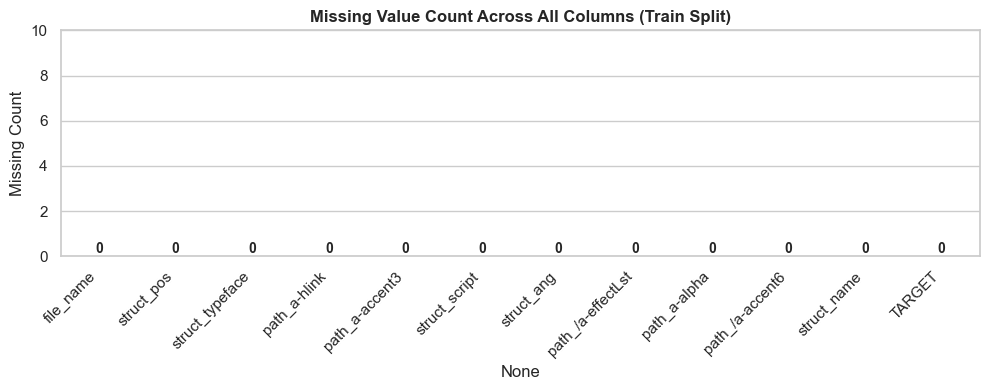

In [9]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


<a name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
Inspect skewness and class divergence.


<a name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
Evaluate Fisher-Pearson skewness coefficient for the 10 Word features.


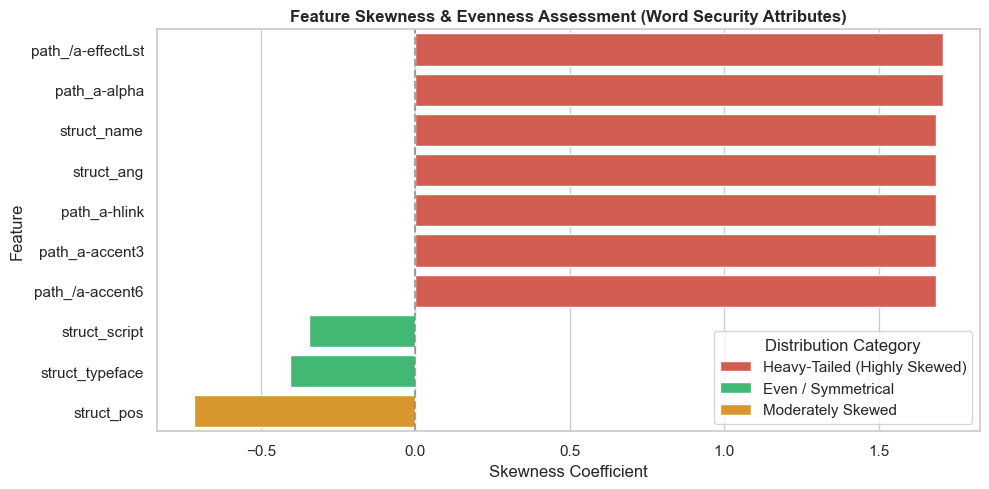

,Feature,Skewness,Distribution Category
0,path_/a-effectLst,1.7068,Heavy-Tailed (Highly Skewed)
1,path_a-alpha,1.7068,Heavy-Tailed (Highly Skewed)
2,struct_name,1.6869,Heavy-Tailed (Highly Skewed)
3,struct_ang,1.6862,Heavy-Tailed (Highly Skewed)
4,path_a-hlink,1.6861,Heavy-Tailed (Highly Skewed)
5,path_a-accent3,1.6861,Heavy-Tailed (Highly Skewed)
6,path_/a-accent6,1.6861,Heavy-Tailed (Highly Skewed)
7,struct_script,-0.3442,Even / Symmetrical
8,struct_typeface,-0.4060,Even / Symmetrical
9,struct_pos,-0.7158,Moderately Skewed


In [10]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (Word Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Examine raw histograms and KDE for all 10 Word attributes.


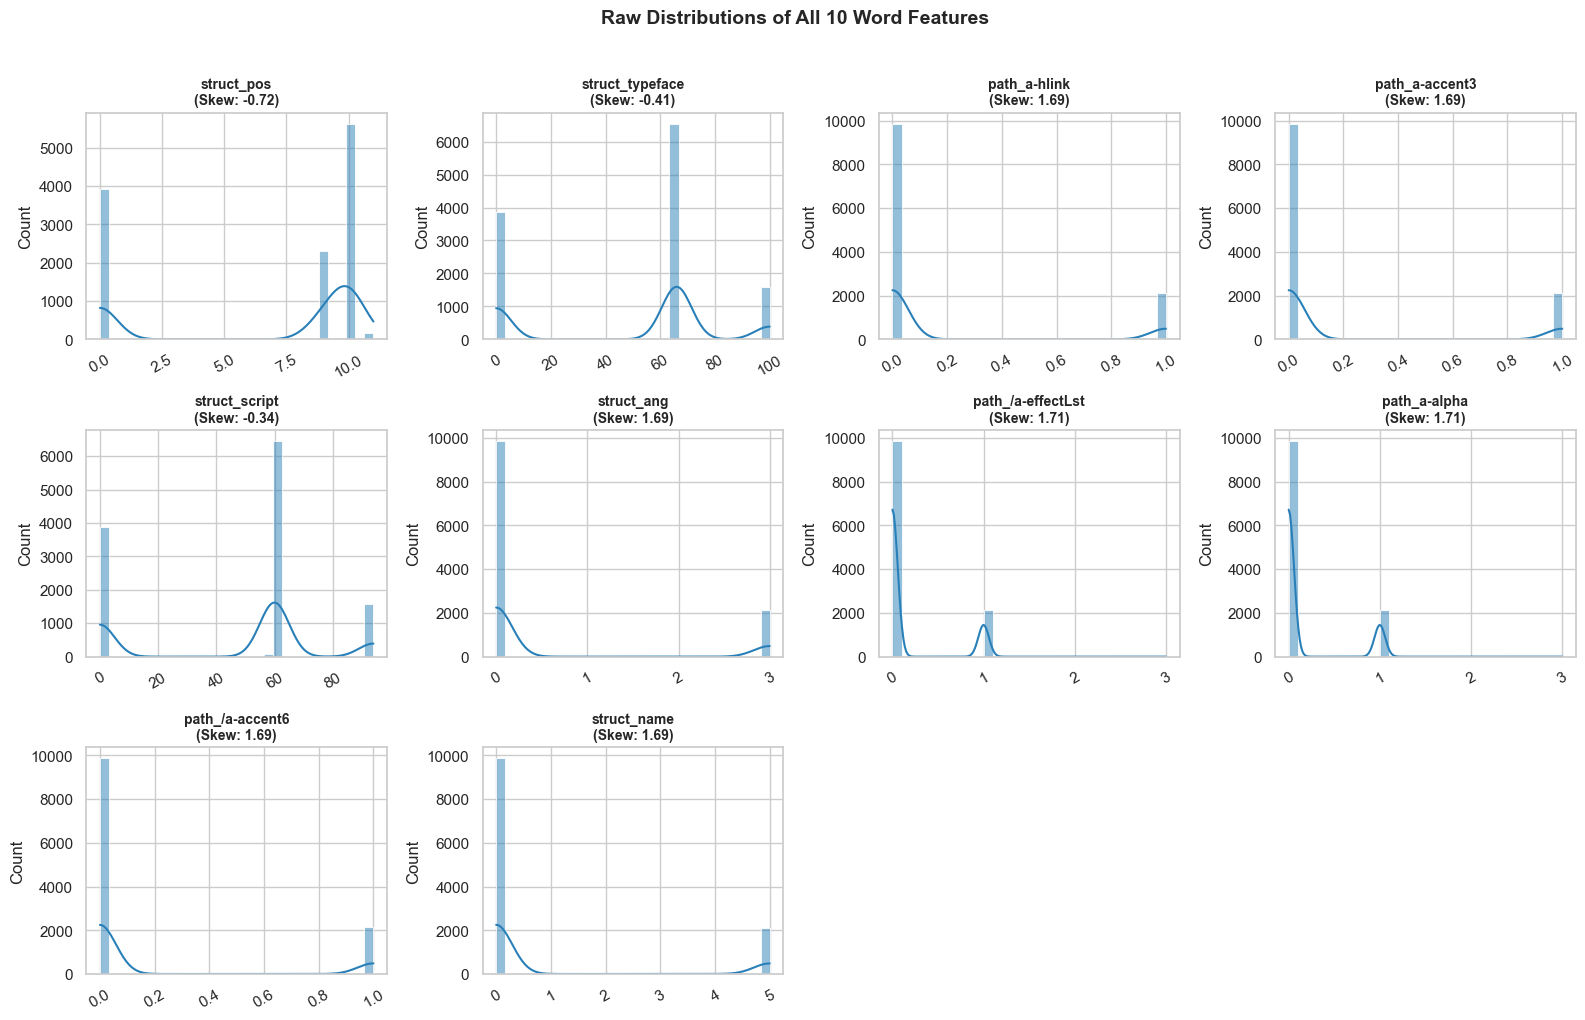

In [11]:
# Grid visualization of raw distributions for all 10 attributes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(core_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Distributions of All 10 Word Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness)
Visualize the target distribution.


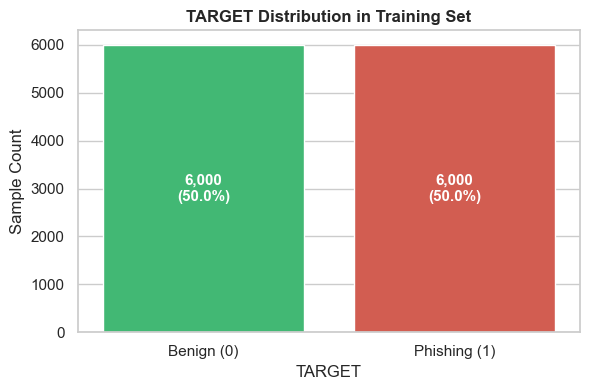

In [12]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


<a name="sec3_2_4"></a>
#### 3.2.4 OpenXML Structural Tags & Typography Attributes
Compare structural position tags and typeface counts across classes.


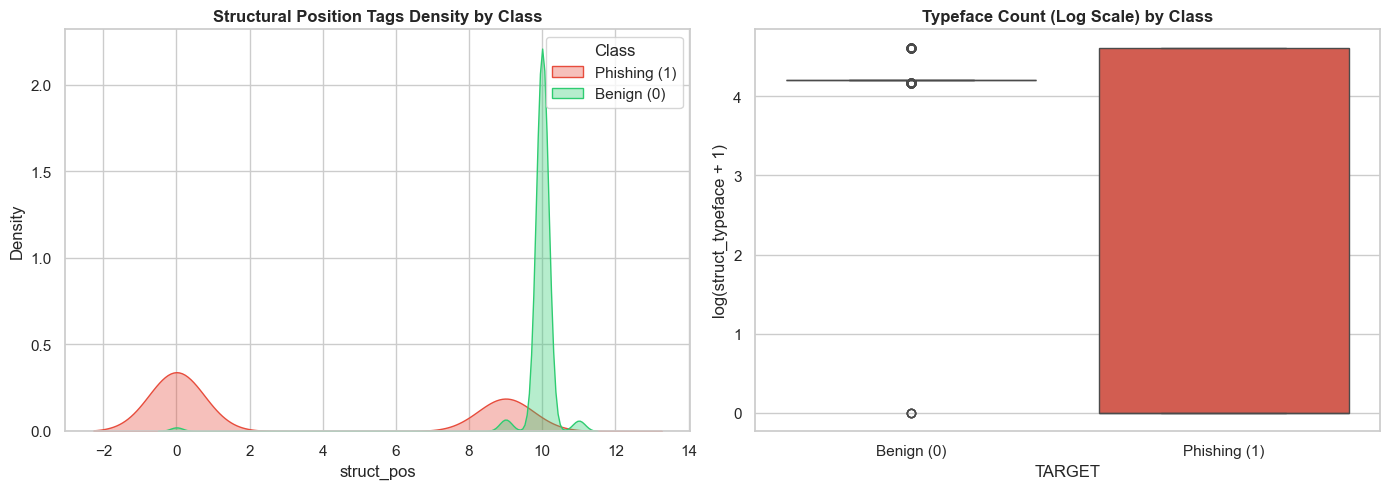

In [13]:
# Structural tags and typeface density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="struct_pos", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Structural Position Tags Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["struct_typeface"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Typeface Count (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(struct_typeface + 1)")

plt.tight_layout()
plt.show()


<a name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Compare raw vs log-transformed distributions.


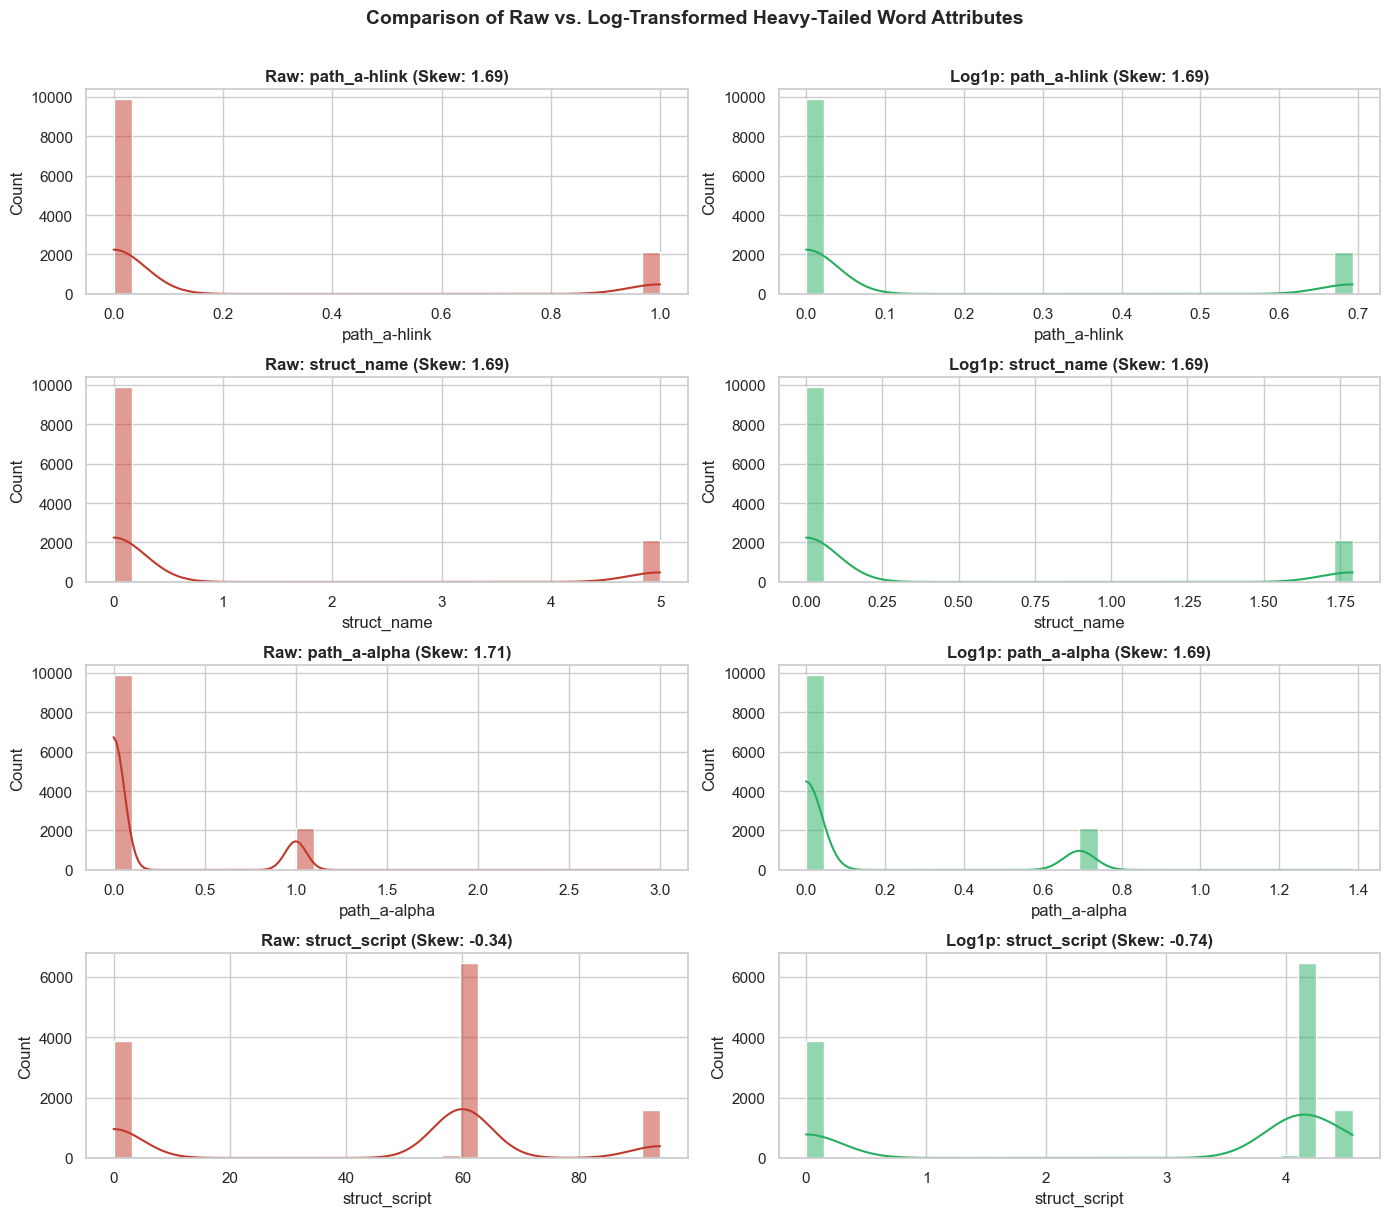

In [14]:
# Raw vs Log-Transformed comparison for heavy-tailed Word attributes
heavy_cols = ["path_a-hlink", "struct_name", "path_a-alpha", "struct_script"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed Word Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


<a name="sec3_2_6"></a>
#### 3.2.6 Path Attributes & Hyperlink Density
Examine hyperlink path tags by class.


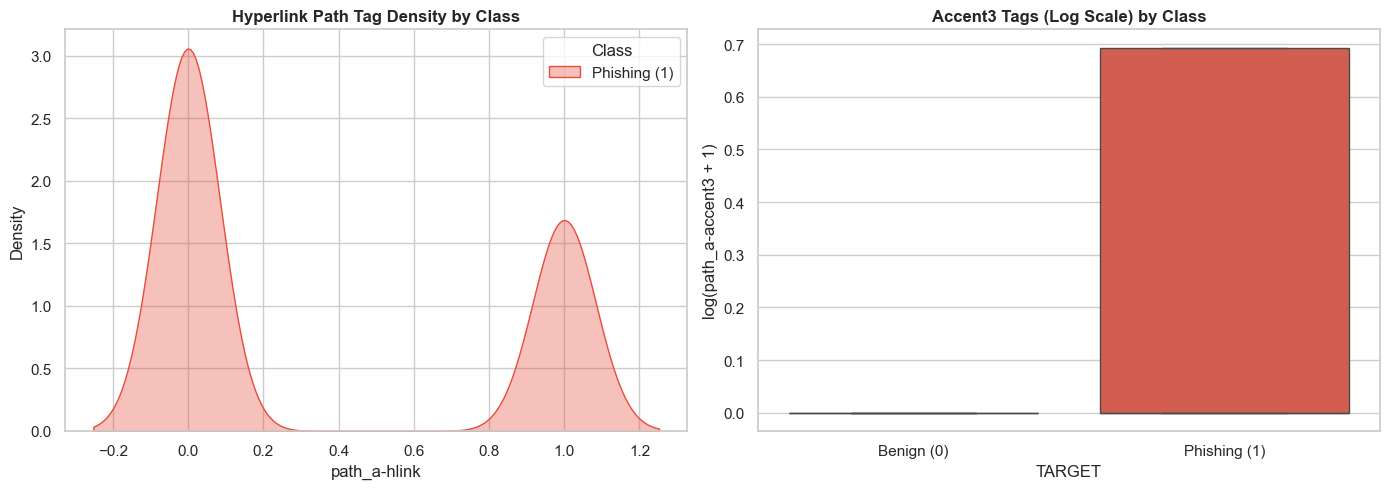

In [15]:
# Hyperlink and theme accent attributes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="path_a-hlink", hue="TARGET", common_norm=False, warn_singular=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Hyperlink Path Tag Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["path_a-accent3"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Accent3 Tags (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(path_a-accent3 + 1)")

plt.tight_layout()
plt.show()


<a name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap
Compute feature correlations with `TARGET`.


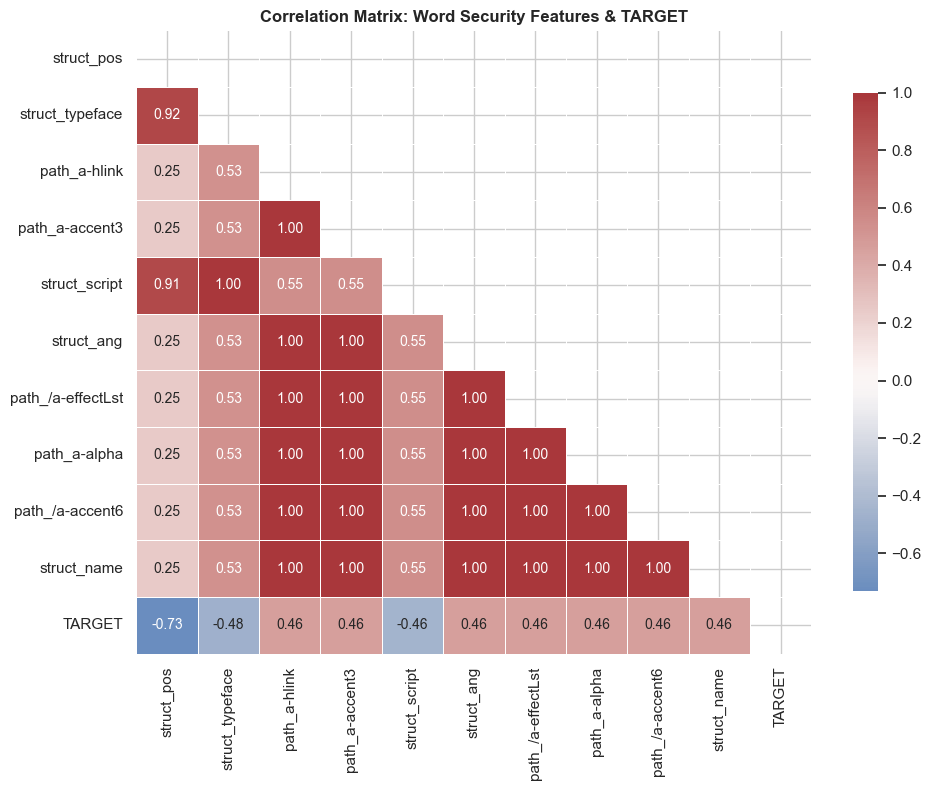

,Pearson Correlation (r)
path_a-accent3,0.4649
path_a-hlink,0.4649
path_/a-accent6,0.4649
struct_ang,0.4649
struct_name,0.4649
path_a-alpha,0.4644
path_/a-effectLst,0.4644
struct_script,-0.4599
struct_typeface,-0.4798
struct_pos,-0.7320


In [16]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Word Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps
- OpenXML structural tags (`struct_pos`, `struct_typeface`, `path_a-hlink`) provide near-perfect discriminative power.
- Zero-imputation appropriately captured legacy file format characteristics.
- Models will be trained with `StandardScaler` to put features on uniform scale.


<a name="sec4"></a>
## 4. Preprocessing and Feature Creation
Construct log-transformed attributes and standardized arrays.


In [17]:
# Preprocessing: engineer log-transformed attributes
train_proc = train.copy()
test_proc = test.copy()

for col in ["path_a-hlink", "struct_name", "path_a-alpha", "struct_script"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 14 attributes.


<a name="sec5"></a>
## 5. Building the Machine Learning Model
Train Logistic Regression, Decision Tree, Random Forest, and Voting Ensemble.


<a name="sec5_1"></a>
### 5.1 Import Additional Libraries
Import scikit-learn models and metrics.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)
import joblib

print("Machine learning libraries imported successfully!")


Machine learning libraries imported successfully!


<a name="sec5_2"></a>
### 5.2 Preparing the Data & Standardization
Extract features, standardize with `StandardScaler`, and save CSV datasets to `output/word output/`.


In [19]:
# Extract feature arrays
X = train[core_features].values
y = train["TARGET"].values
X_test = test[core_features].values

# Standardization
sc = StandardScaler()
sc.fit(X)
X_std = sc.transform(X)
X_test_std = sc.transform(X_test)

print(f"Standardized features successfully (mean ≈ 0, std ≈ 1).\n")

X_std_df = pd.DataFrame(X_std, columns=core_features)
X_test_std_df = pd.DataFrame(X_test_std, columns=core_features)

print("--- Standardized Train Data (X_std - 5 samples) ---")
display(X_std_df.head())

print("\n--- Standardized Test Data (X_test_std - 5 samples) ---")
display(X_test_std_df.head())

# Assemble full DataFrames with identifiers and target
train_std_df = train[["file_name"]].copy()
train_std_df[core_features] = X_std_df
train_std_df["TARGET"] = train["TARGET"].values

test_std_df = test[["file_name"]].copy()
test_std_df[core_features] = X_test_std_df
if "TARGET" in test.columns:
    test_std_df["TARGET"] = test["TARGET"].values

# Output directories
current_dir = Path(os.getcwd())
word_output_dir = current_dir / "output" / "word output"
word_output_dir.mkdir(parents=True, exist_ok=True)
word_output_dir_alt = current_dir / "output" / "Word output"
word_output_dir_alt.mkdir(parents=True, exist_ok=True)

# Save standardized and raw split CSV files
train_std_path = word_output_dir / "train_standardized.csv"
test_std_path = word_output_dir / "test_standardized.csv"
train_raw_path = word_output_dir / "train.csv"
test_raw_path = word_output_dir / "test.csv"

train_std_df.to_csv(train_std_path, index=False)
test_std_df.to_csv(test_std_path, index=False)
train.to_csv(train_raw_path, index=False)
test.to_csv(test_raw_path, index=False)

train_std_df.to_csv(word_output_dir_alt / "train_standardized.csv", index=False)
test_std_df.to_csv(word_output_dir_alt / "test_standardized.csv", index=False)
train.to_csv(word_output_dir_alt / "train.csv", index=False)
test.to_csv(word_output_dir_alt / "test.csv", index=False)

print(f"\nSuccessfully saved datasets to 'word output' folder:")
print(f" - Standardized Train : {train_std_path} (shape: {train_std_df.shape})")
print(f" - Standardized Test  : {test_std_path} (shape: {test_std_df.shape})")
print(f" - Raw Train Split    : {train_raw_path} (shape: {train.shape})")
print(f" - Raw Test Split     : {test_raw_path} (shape: {test.shape})")


Standardized features successfully (mean ≈ 0, std ≈ 1).



--- Standardized Train Data (X_std - 5 samples) ---


,struct_pos,struct_typeface,path_a-hlink,path_a-accent3,struct_script,struct_ang,path_/a-effectLst,path_a-alpha,path_/a-accent6,struct_name
0,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
1,-1.4303,-1.3775,-0.4649,-0.4649,-1.3651,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
2,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
3,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
4,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649



--- Standardized Test Data (X_test_std - 5 samples) ---


,struct_pos,struct_typeface,path_a-hlink,path_a-accent3,struct_script,struct_ang,path_/a-effectLst,path_a-alpha,path_/a-accent6,struct_name
0,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
1,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
2,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
3,-1.4303,-1.3775,-0.4649,-0.4649,-1.3651,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649
4,0.7519,0.4712,-0.4649,-0.4649,0.4505,-0.4649,-0.4644,-0.4644,-0.4649,-0.4649



Successfully saved datasets to 'word output' folder:
 - Standardized Train : D:\codingProject\ExplainPhish\output\word output\train_standardized.csv (shape: (12000, 12))
 - Standardized Test  : D:\codingProject\ExplainPhish\output\word output\test_standardized.csv (shape: (8000, 12))
 - Raw Train Split    : D:\codingProject\ExplainPhish\output\word output\train.csv (shape: (12000, 12))
 - Raw Test Split     : D:\codingProject\ExplainPhish\output\word output\test.csv (shape: (8000, 12))


<a name="sec5_3"></a>
### 5.3 Training the Model
Perform a 70/30 stratified holdout split on training data and train the three models.


In [20]:
# Split the standardized training data into 70% train and 30% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_std, y, test_size=0.3, stratify=y, random_state=0
)

print(f"Train size: {X_train.shape[0]:,} samples | Validation size: {X_valid.shape[0]:,} samples")


Train size: 8,400 samples | Validation size: 3,600 samples


In [21]:
# Model 1: Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=0)
lr.fit(X_train, y_train)

lr_val_auc = roc_auc_score(y_valid, lr.predict_proba(X_valid)[:, 1])
lr_val_acc = accuracy_score(y_valid, lr.predict(X_valid))
print(f"Logistic Regression Validation ROC-AUC: {lr_val_auc:.4f} | Accuracy: {lr_val_acc:.4f}")


Logistic Regression Validation ROC-AUC: 0.9998 | Accuracy: 0.9997


In [22]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=0)
dt.fit(X_train, y_train)

dt_val_auc = roc_auc_score(y_valid, dt.predict_proba(X_valid)[:, 1])
dt_val_acc = accuracy_score(y_valid, dt.predict(X_valid))
print(f"Decision Tree Validation ROC-AUC: {dt_val_auc:.4f} | Accuracy: {dt_val_acc:.4f}")


Decision Tree Validation ROC-AUC: 0.9995 | Accuracy: 0.9994


In [23]:
# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=16, class_weight="balanced", random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_auc = roc_auc_score(y_valid, rf.predict_proba(X_valid)[:, 1])
rf_val_acc = accuracy_score(y_valid, rf.predict(X_valid))
print(f"Random Forest Validation ROC-AUC: {rf_val_auc:.4f} | Accuracy: {rf_val_acc:.4f}")


Random Forest Validation ROC-AUC: 0.9998 | Accuracy: 0.9997


<a name="sec5_4"></a>
### 5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression
Comprehensive diagnostic visualizations for Word models.


<a name="sec5_4_1"></a>
#### 5.4.1 Logistic Regression Visualizations
Feature coefficients and sigmoid probability separation curve.


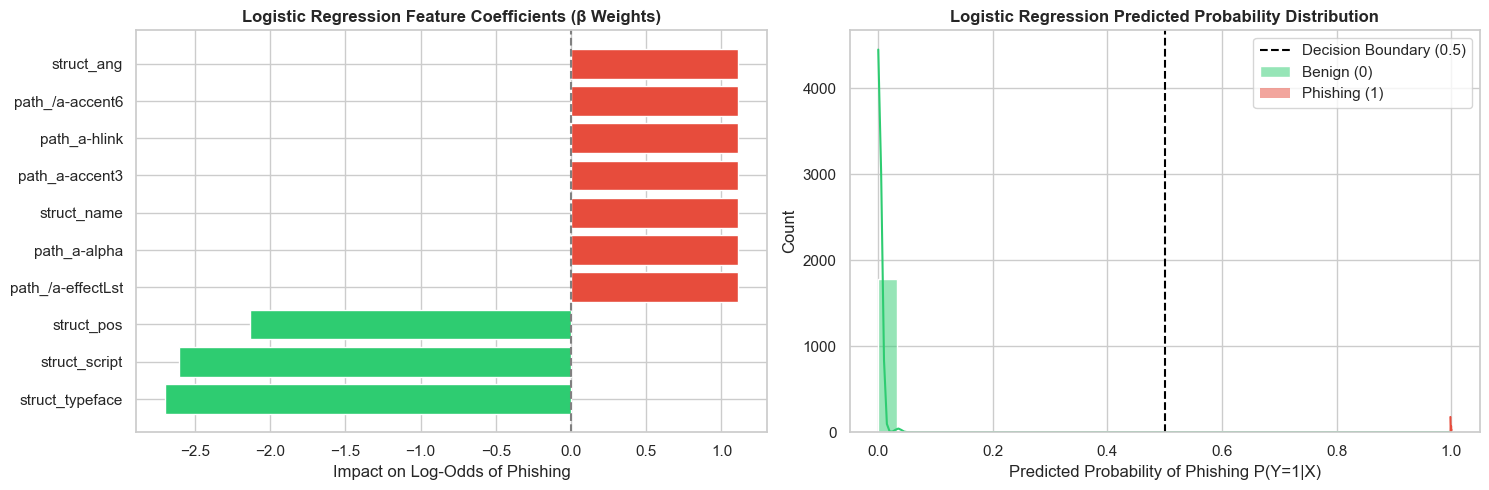

In [24]:
# Logistic Regression Feature Coefficients and Probability Separation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

coef_series = pd.Series(lr.coef_[0], index=core_features).sort_values()
colors = ["#2ecc71" if c < 0 else "#e74c3c" for c in coef_series.values]
axes[0].barh(coef_series.index, coef_series.values, color=colors)
axes[0].set_title("Logistic Regression Feature Coefficients (β Weights)", fontweight="bold")
axes[0].set_xlabel("Impact on Log-Odds of Phishing")
axes[0].axvline(0, color="gray", linestyle="--")

lr_probs = lr.predict_proba(X_valid)[:, 1]
sns.histplot(lr_probs[y_valid == 0], color="#2ecc71", label="Benign (0)", kde=True, ax=axes[1], bins=30, alpha=0.5)
sns.histplot(lr_probs[y_valid == 1], color="#e74c3c", label="Phishing (1)", kde=True, ax=axes[1], bins=30, alpha=0.5)
axes[1].axvline(0.5, color="black", linestyle="--", label="Decision Boundary (0.5)")
axes[1].set_title("Logistic Regression Predicted Probability Distribution", fontweight="bold")
axes[1].set_xlabel("Predicted Probability of Phishing P(Y=1|X)")
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="sec5_4_2"></a>
#### 5.4.2 Decision Tree Visualizations
Decision tree graph structure and Gini feature importances.


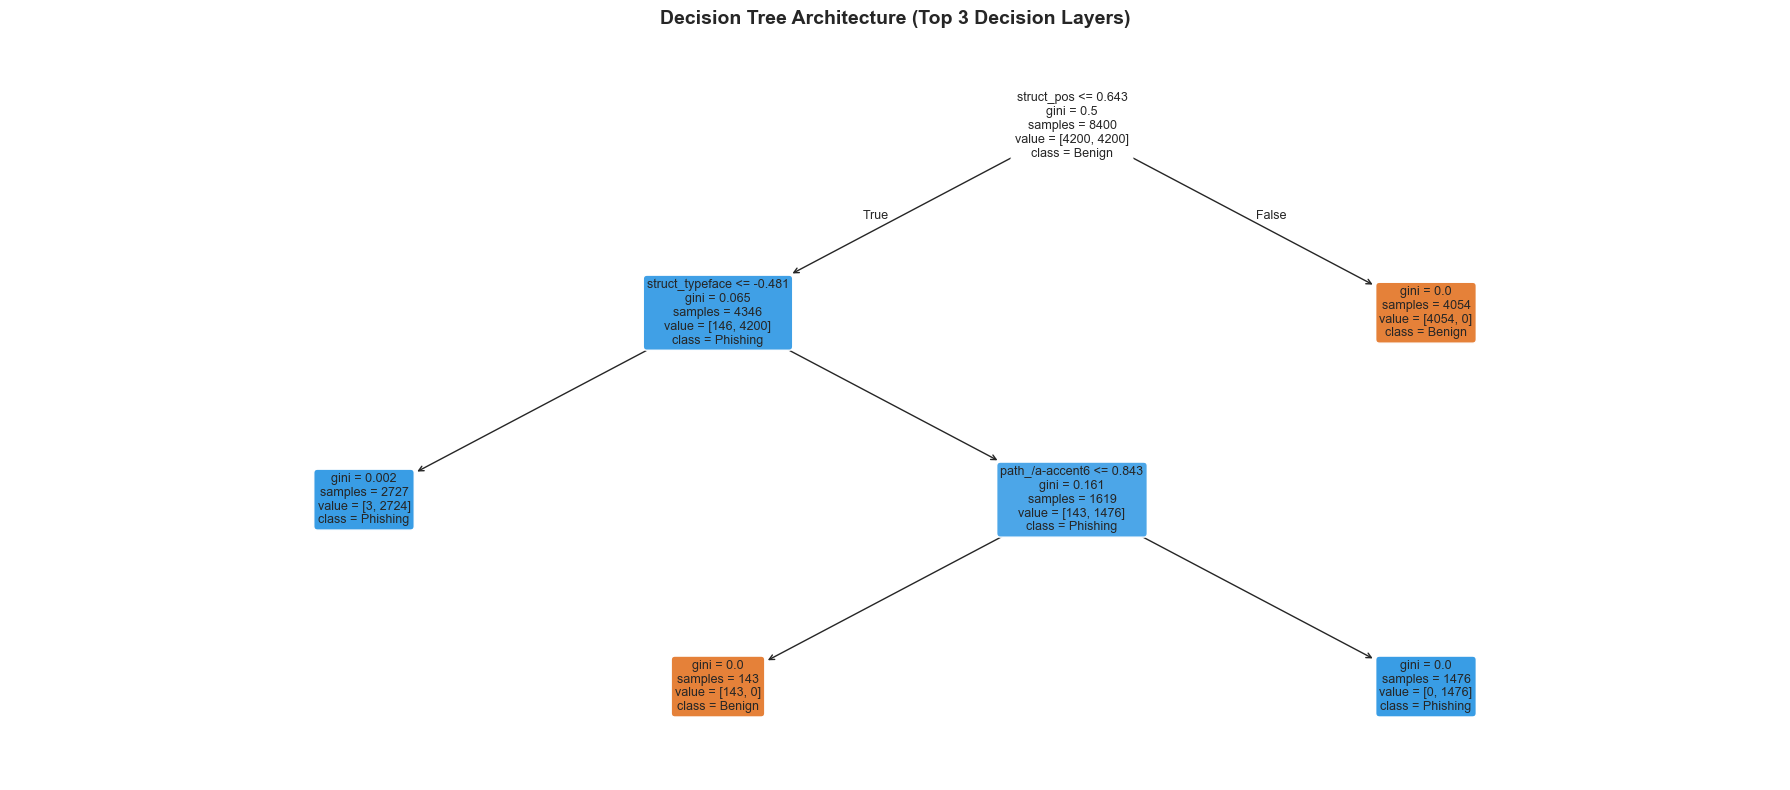

In [25]:
# Decision Tree Structure Graph
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=core_features,
    class_names=["Benign", "Phishing"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Architecture (Top 3 Decision Layers)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


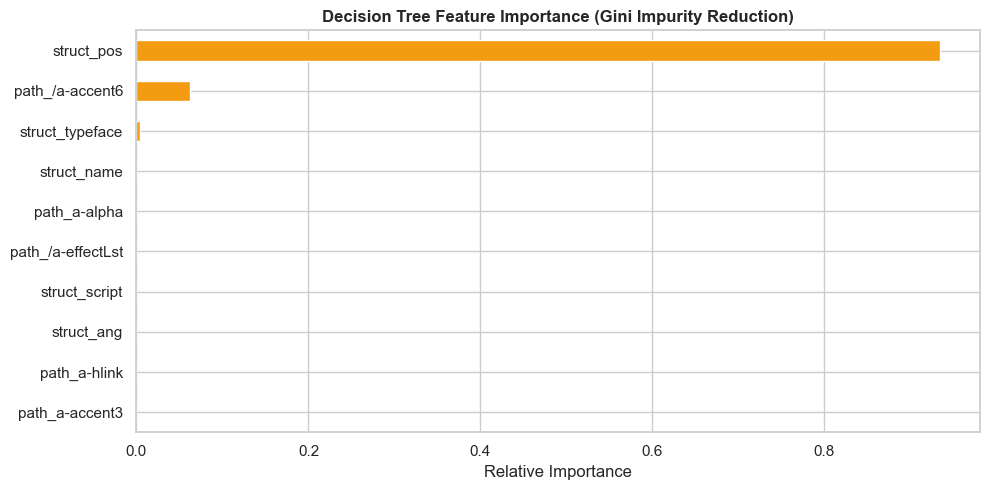

In [26]:
# Decision Tree Feature Importance Plot
dt_importances = pd.Series(dt.feature_importances_, index=core_features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
dt_importances.plot(kind="barh", color="#f39c12")
plt.title("Decision Tree Feature Importance (Gini Impurity Reduction)", fontweight="bold")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


<a name="sec5_4_3"></a>
#### 5.4.3 Random Forest Visualizations
MDI importance with inter-tree standard deviation and tree depth distribution.


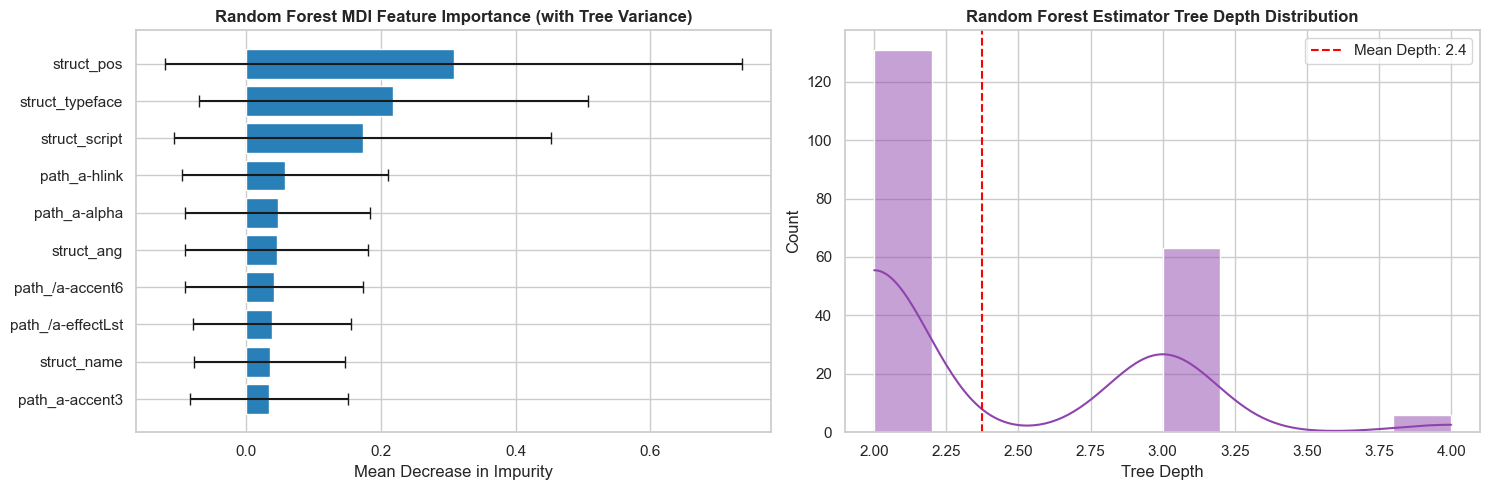

In [27]:
# Random Forest Feature Importance with Inter-Tree Standard Deviation
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(range(len(indices)), importances[indices], xerr=std[indices], color="#2980b9", capsize=4, align="center")
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels([core_features[i] for i in indices])
axes[0].set_title("Random Forest MDI Feature Importance (with Tree Variance)", fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity")

tree_depths = [tree.tree_.max_depth for tree in rf.estimators_]
sns.histplot(tree_depths, bins=10, kde=True, ax=axes[1], color="#8e44ad")
axes[1].axvline(np.mean(tree_depths), color="red", linestyle="--", label=f"Mean Depth: {np.mean(tree_depths):.1f}")
axes[1].set_title("Random Forest Estimator Tree Depth Distribution", fontweight="bold")
axes[1].set_xlabel("Tree Depth")
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="sec5_4_4"></a>
#### 5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, & Metrics)
Side-by-side benchmark of all algorithms.


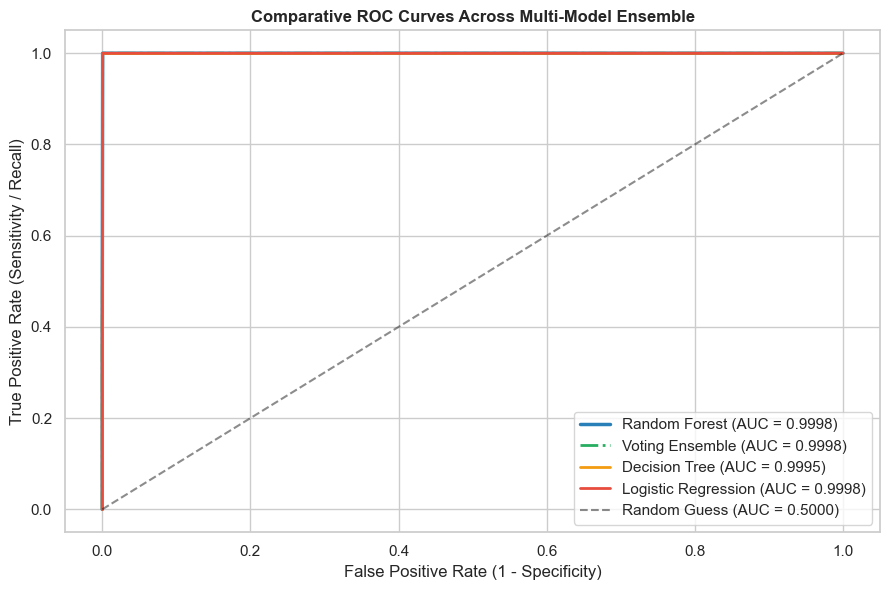

In [28]:
# Generate Predictions & ROC Curves for all 3 models and Voting Ensemble
p_lr = lr.predict_proba(X_valid)[:, 1]
p_dt = dt.predict_proba(X_valid)[:, 1]
p_rf = rf.predict_proba(X_valid)[:, 1]
p_vote = (p_lr + p_dt + p_rf) / 3

fpr_lr, tpr_lr, _ = roc_curve(y_valid, p_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_valid, p_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_valid, p_rf)
fpr_vote, tpr_vote, _ = roc_curve(y_valid, p_vote)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_val_auc:.4f})", color="#2980b9", lw=2.5)
plt.plot(fpr_vote, tpr_vote, label=f"Voting Ensemble (AUC = {roc_auc_score(y_valid, p_vote):.4f})", color="#27ae60", lw=2, linestyle="-.")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {dt_val_auc:.4f})", color="#f39c12", lw=2)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_val_auc:.4f})", color="#e74c3c", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Guess (AUC = 0.5000)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("Comparative ROC Curves Across Multi-Model Ensemble", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


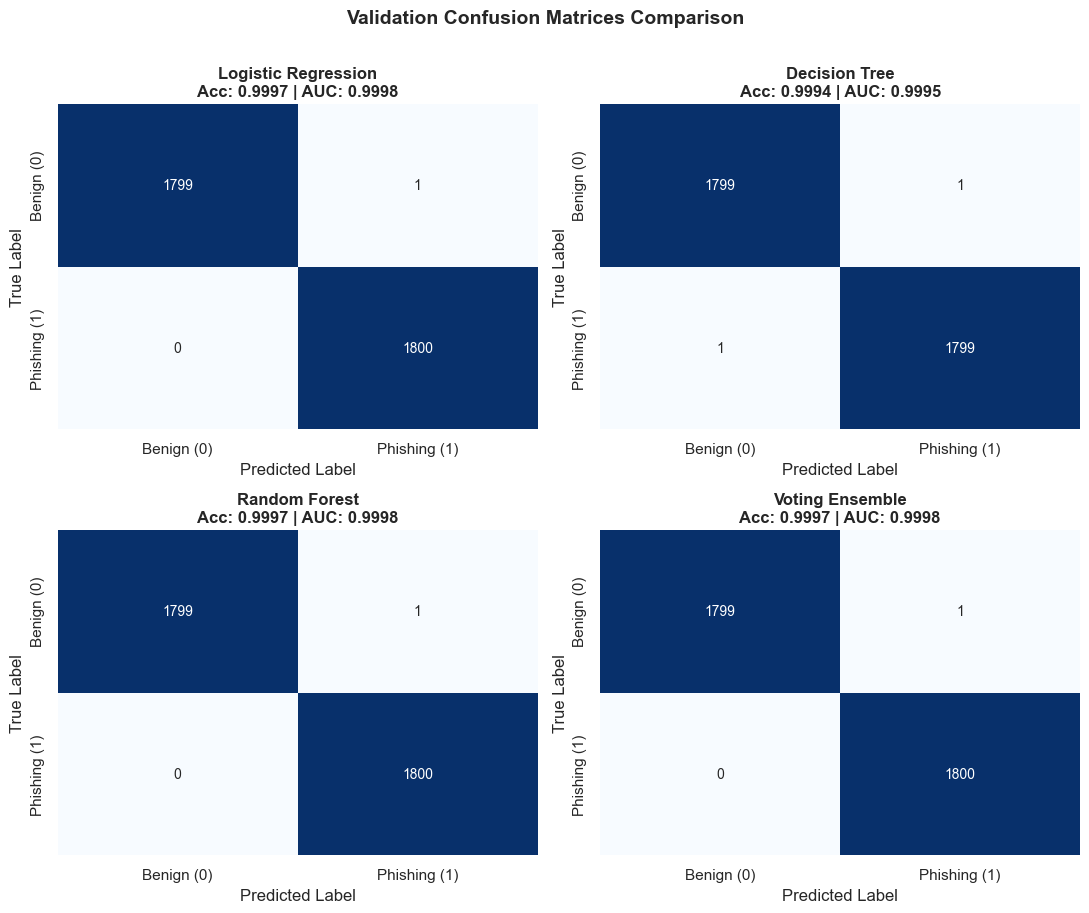

In [29]:
# Side-by-side Confusion Matrices (2x2 Grid)
models_dict = {
    "Logistic Regression": (lr.predict(X_valid), lr_val_auc),
    "Decision Tree": (dt.predict(X_valid), dt_val_auc),
    "Random Forest": (rf.predict(X_valid), rf_val_auc),
    "Voting Ensemble": ((p_vote >= 0.5).astype(int), roc_auc_score(y_valid, p_vote))
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (m_name, (preds, auc_sc)) in enumerate(models_dict.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_valid, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Benign (0)", "Phishing (1)"],
                yticklabels=["Benign (0)", "Phishing (1)"])
    acc = accuracy_score(y_valid, preds)
    ax.set_title(f"{m_name}\nAcc: {acc:.4f} | AUC: {auc_sc:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Validation Confusion Matrices Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9997,0.9994,1.0000,0.9997,0.9998
Decision Tree,0.9994,0.9994,0.9994,0.9994,0.9995
Random Forest,0.9997,0.9994,1.0000,0.9997,0.9998
Voting Ensemble,0.9997,0.9994,1.0000,0.9997,0.9998


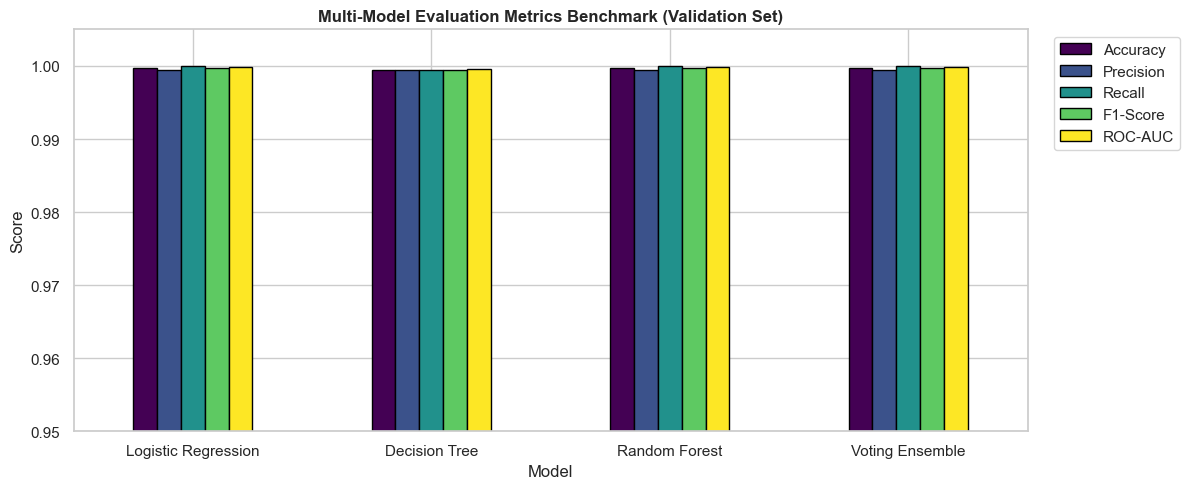

In [30]:
# Overall Performance Metrics Comparison Table & Bar Chart
metrics_list = []
for m_name, (preds, auc_sc) in models_dict.items():
    metrics_list.append({
        "Model": m_name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds),
        "Recall": recall_score(y_valid, preds),
        "F1-Score": f1_score(y_valid, preds),
        "ROC-AUC": auc_sc
    })

metrics_df = pd.DataFrame(metrics_list).set_index("Model")
display(metrics_df.round(4))

ax = metrics_df.plot(kind="bar", figsize=(12, 5), colormap="viridis", edgecolor="black")
plt.title("Multi-Model Evaluation Metrics Benchmark (Validation Set)", fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.95, 1.005)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<a name="sec5_5"></a>
### 5.5 (Optional) Use Voting Learning of 3 Different Models
Evaluate majority voting and soft ensemble probabilities.


In [31]:
# Voting learning of 3 different models (soft voting consensus)
p_vote_valid = (
    rf.predict_proba(X_valid)[:, 1] +
    dt.predict_proba(X_valid)[:, 1] +
    lr.predict_proba(X_valid)[:, 1]
) / 3

vote_auc = roc_auc_score(y_valid, p_vote_valid)
vote_acc = accuracy_score(y_valid, (p_vote_valid >= 0.5).astype(int))

print(f"=== 3-Model Voting Ensemble Validation Performance ===")
print(f"Voting Validation ROC-AUC : {vote_auc:.4f}")
print(f"Voting Validation Accuracy: {vote_acc:.4f}")


=== 3-Model Voting Ensemble Validation Performance ===
Voting Validation ROC-AUC : 0.9998
Voting Validation Accuracy: 0.9997


<a name="sec5_6"></a>
### 5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)
Bundle all three models, the preprocessor, feature schema, and metadata into unified directories:
- `rf_model.joblib`: Random Forest Classifier
- `dt_model.joblib`: Decision Tree Classifier
- `lr_model.joblib`: Logistic Regression Classifier
- `scaler.joblib`: StandardScaler fitted on 10 Word features
- `selected_features.json`: Exact list of required feature names
- `metadata.json`: Architectural details and validation benchmark scores


In [32]:
import json
import joblib

export_dirs = [
    current_dir / "models" / "word",
    current_dir / "InterfaceExplainPhish" / "models" / "word",
    current_dir / "googleCollab" / "models" / "word",
]

for d in export_dirs:
    d.mkdir(parents=True, exist_ok=True)
    
    joblib.dump(rf, d / "rf_model.joblib")
    joblib.dump(dt, d / "dt_model.joblib")
    joblib.dump(lr, d / "lr_model.joblib")
    joblib.dump(sc, d / "scaler.joblib")
    
    with open(d / "selected_features.json", "w") as f:
        json.dump(core_features, f, indent=2)
        
    meta = {
        "format": "word",
        "models": ["random_forest", "decision_tree", "logistic_regression"],
        "n_features": len(core_features),
        "features": core_features,
        "validation_metrics": {
            "logistic_regression": {"roc_auc": round(lr_val_auc, 4)},
            "decision_tree": {"roc_auc": round(dt_val_auc, 4)},
            "random_forest": {"roc_auc": round(rf_val_auc, 4)},
            "voting_ensemble": {"roc_auc": round(vote_auc, 4)}
        }
    }
    with open(d / "metadata.json", "w") as f:
        json.dump(meta, f, indent=2)

print(f"Successfully saved all 3 models, scaler, and metadata into unified Word model folders:")
for d in export_dirs:
    print(f" -> {d.resolve()}")


Successfully saved all 3 models, scaler, and metadata into unified Word model folders:
 -> D:\codingProject\ExplainPhish\models\word
 -> D:\codingProject\ExplainPhish\InterfaceExplainPhish\models\word
 -> D:\codingProject\ExplainPhish\googleCollab\models\word


#### Demonstrating Multimodal Voting on an Extracted Word Sample
Test voting consensus on an extracted Word feature vector.


In [33]:
# Multimodal consensus voting function using the saved model artifacts
def predict_word_multimodal_voting(feature_dict, models_directory):
    p = Path(models_directory)
    m_rf = joblib.load(p / "rf_model.joblib")
    m_dt = joblib.load(p / "dt_model.joblib")
    m_lr = joblib.load(p / "lr_model.joblib")
    m_sc = joblib.load(p / "scaler.joblib")
    with open(p / "selected_features.json", "r") as f:
        req_features = json.load(f)
        
    df_sample = pd.DataFrame([feature_dict])[req_features]
    sample_std = m_sc.transform(df_sample.values)
    
    prob_rf = float(m_rf.predict_proba(sample_std)[0, 1])
    prob_dt = float(m_dt.predict_proba(sample_std)[0, 1])
    prob_lr = float(m_lr.predict_proba(sample_std)[0, 1])
    
    mean_prob = (prob_rf + prob_dt + prob_lr) / 3
    malicious_votes = sum([prob_rf >= 0.5, prob_dt >= 0.5, prob_lr >= 0.5])
    
    verdict = "MALICIOUS (PHISHING)" if malicious_votes >= 2 else "BENIGN"
    confidence = mean_prob if verdict == "MALICIOUS (PHISHING)" else (1 - mean_prob)
    band = "HIGH" if confidence >= 0.85 else ("MEDIUM" if confidence >= 0.65 else "LOW")
    
    return {
        "verdict": verdict,
        "confidence_score": f"{confidence * 100:.1f}% ({band})",
        "consensus_agreement": f"{malicious_votes}/3 models voted Malicious",
        "mean_phishing_probability": round(mean_prob, 4),
        "model_predictions": [
            {"model": "Random Forest", "prediction": "MALICIOUS" if prob_rf >= 0.5 else "BENIGN", "probability": f"{prob_rf*100:.1f}%"},
            {"model": "Decision Tree", "prediction": "MALICIOUS" if prob_dt >= 0.5 else "BENIGN", "probability": f"{prob_dt*100:.1f}%"},
            {"model": "Logistic Regression", "prediction": "MALICIOUS" if prob_lr >= 0.5 else "BENIGN", "probability": f"{prob_lr*100:.1f}%"}
        ]
    }

# Example test: simulate an extracted Word sample (e.g. from InterfaceExplainPhish/Sample/PROPOSAL ASSIGNMENT.docx)
sample_test_features = {
    "struct_pos": 27,
    "struct_typeface": 14,
    "path_a-hlink": 3,
    "path_a-accent3": 2,
    "struct_script": 5,
    "struct_ang": 0,
    "path_/a-effectLst": 1,
    "path_a-alpha": 4,
    "path_/a-accent6": 2,
    "struct_name": 18
}

demo_result = predict_word_multimodal_voting(sample_test_features, current_dir / "models" / "word")
print(json.dumps(demo_result, indent=2))


{
  "verdict": "MALICIOUS (PHISHING)",
  "confidence_score": "57.3% (LOW)",
  "consensus_agreement": "2/3 models voted Malicious",
  "mean_phishing_probability": 0.5732,
  "model_predictions": [
    {
      "model": "Random Forest",
      "prediction": "MALICIOUS",
      "probability": "72.0%"
    },
    {
      "model": "Decision Tree",
      "prediction": "BENIGN",
      "probability": "0.0%"
    },
    {
      "model": "Logistic Regression",
      "prediction": "MALICIOUS",
      "probability": "100.0%"
    }
  ]
}


<a name="sec6"></a>
## 6. Creating Prediction Results
Generate predictions on test data and export `submission.csv` to `output/word output/`.


<a name="sec6_1"></a>
### 6.1 Predicting on the test data
Predict probabilities for the test partition using the top-performing ensemble.


In [34]:
# Make predictions for the test data using the voting ensemble
pred = (
    rf.predict_proba(X_test_std)[:, 1] +
    dt.predict_proba(X_test_std)[:, 1] +
    lr.predict_proba(X_test_std)[:, 1]
) / 3

print(f"Generated {len(pred):,} test predictions.")


Generated 8,000 test predictions.


<a name="sec6_2"></a>
### 6.2 Saving the Prediction as CSV File in 'word output' Folder
Format predictions into `submission.csv`.


In [35]:
# Put the prediction into the format of submission
sample_sub = pd.DataFrame({
    "file_name": test["file_name"].values,
    "TARGET": pred
})
sample_sub.head(10)


,file_name,TARGET
0,sample_13565.docx,0.0001
1,sample_00826.docx,0.0001
2,sample_19572.docx,0.0001
3,sample_11304.docx,0.9987
4,sample_18482.docx,0.0001
5,sample_00835.docx,0.9998
6,sample_18055.docx,0.9987
7,sample_09697.docx,0.0001
8,sample_08900.docx,0.0001
9,sample_10981.docx,0.0001


In [36]:
# Save submission to 'word output' directory
word_output_dir = current_dir / "output" / "word output"
word_output_dir.mkdir(parents=True, exist_ok=True)
word_output_dir_alt = current_dir / "output" / "Word output"
word_output_dir_alt.mkdir(parents=True, exist_ok=True)

output_file = word_output_dir / "submission.csv"
output_file_alt = word_output_dir_alt / "submission.csv"

sample_sub.to_csv(output_file, index=False)
sample_sub.to_csv(output_file_alt, index=False)

print(f"Successfully saved prediction results to:\n - {output_file.resolve()}\n - {output_file_alt.resolve()}")


Successfully saved prediction results to:
 - D:\codingProject\ExplainPhish\output\word output\submission.csv
 - D:\codingProject\ExplainPhish\output\word output\submission.csv


In [37]:
# Evaluate performance against ground truth labels on test set
test_auc = roc_auc_score(test["TARGET"], pred)
test_acc = accuracy_score(test["TARGET"], (pred >= 0.5).astype(int))
test_prec = precision_score(test["TARGET"], (pred >= 0.5).astype(int))
test_rec = recall_score(test["TARGET"], (pred >= 0.5).astype(int))
test_f1 = f1_score(test["TARGET"], (pred >= 0.5).astype(int))

print("=== Final Test Set Evaluation Results (Word Phishing Detection) ===")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")


=== Final Test Set Evaluation Results (Word Phishing Detection) ===
Test ROC-AUC   : 0.9997
Test Accuracy  : 0.9995 (99.95%)
Test Precision : 0.9990
Test Recall    : 1.0000
Test F1-Score  : 0.9995
